In [129]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")
import matplotlib.gridspec as gridspec


In [88]:
orders       = pd.read_csv("olist_orders_dataset.csv")
order_items  = pd.read_csv("olist_order_items_dataset.csv")
customers    = pd.read_csv("olist_customers_dataset.csv")
products     = pd.read_csv("olist_products_dataset.csv")
sellers      = pd.read_csv("olist_sellers_dataset.csv")
payments     = pd.read_csv("olist_order_payments_dataset.csv")
reviews      = pd.read_csv("olist_order_reviews_dataset.csv")
geolocation  = pd.read_csv("olist_geolocation_dataset.csv")
category_tr  = pd.read_csv("product_category_name_translation.csv")

In [89]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [90]:
for name, df in [("orders", orders), ("order_items", order_items),
                  ("customers", customers), ("products", products),
                  ("sellers", sellers), ("payments", payments),
                  ("reviews", reviews), ("category_translation", category_tr)]:
    print(f"  {name:25s} : {df.shape[0]:>7,} rows  {df.shape[1]:>2} cols")

  orders                    :  99,441 rows   8 cols
  order_items               : 112,650 rows   7 cols
  customers                 :  99,441 rows   5 cols
  products                  :  32,951 rows   9 cols
  sellers                   :   3,095 rows   4 cols
  payments                  : 103,886 rows   5 cols
  reviews                   :  99,224 rows   7 cols
  category_translation      :      71 rows   2 cols


In [91]:
print("\n" + "=" * 55)
print("COLUMN NAMES")
print("=" * 55)
for name, df in [("orders", orders), ("order_items", order_items),
                  ("customers", customers), ("products", products),
                  ("payments", payments), ("reviews", reviews)]:
    print(f"\n{name}:")
    print(f"  {df.columns.tolist()}")


COLUMN NAMES

orders:
  ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_items:
  ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

customers:
  ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

products:
  ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

payments:
  ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

reviews:
  ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [92]:
print("\n" + "=" * 55)
print("MERGING TABLES")
print("=" * 55)
df = orders.merge(customers , on = "customer_id" , how ="left")
print(f"after order + customers :{df.shape}")

df = df.merge(order_items , on="order_id" , how  = "left")
print(f"After + products             : {df.shape}")

df = df.merge(products, on="product_id", how="left")
print(f"After + products             : {df.shape}")

df = df.merge(category_tr , on = "product_category_name" , how = "left")
print(f"After + category translation : {df.shape}")

df = df.merge(sellers , on = "seller_id" , how = "left")
print(f"After + sellers              : {df.shape}")


MERGING TABLES
after order + customers :(99441, 12)
After + products             : (113425, 18)
After + products             : (113425, 26)
After + category translation : (113425, 27)
After + sellers              : (113425, 30)


In [93]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP


In [94]:
pay_agg = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    payment_type=("payment_type", "first"),
    payment_installments=("payment_installments", "max")
).reset_index()
df = df.merge(pay_agg, on="order_id", how="left")
print(f"After + payments             : {df.shape}")

After + payments             : (113425, 33)


In [95]:
rev_agg = reviews.sort_values("review_creation_date").groupby("order_id").agg(
    review_score=("review_score", "last"),
    review_comment=("review_comment_message", "last")
).reset_index()
df = df.merge(rev_agg, on="order_id", how="left")
print(f"After + reviews              : {df.shape}")

After + reviews              : (113425, 35)


In [96]:
print("\n" + "=" * 55)
print("MISSING VALUES (top columns)")
print("=" * 55)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
for col, count in missing.head(15).items():
    print(f"  {col:45s} : {count:>7,}  ({count/len(df)*100:.1f}%)")


MISSING VALUES (top columns)
  review_comment                                :  65,430  (57.7%)
  order_delivered_customer_date                 :   3,229  (2.8%)
  product_category_name_english                 :   2,402  (2.1%)
  product_photos_qty                            :   2,378  (2.1%)
  product_category_name                         :   2,378  (2.1%)
  product_name_lenght                           :   2,378  (2.1%)
  product_description_lenght                    :   2,378  (2.1%)
  order_delivered_carrier_date                  :   1,968  (1.7%)
  review_score                                  :     961  (0.8%)
  product_width_cm                              :     793  (0.7%)
  product_height_cm                             :     793  (0.7%)
  product_length_cm                             :     793  (0.7%)
  product_weight_g                              :     793  (0.7%)
  freight_value                                 :     775  (0.7%)
  price                                      

In [97]:
print("\n" + "=" * 55)
print("KEY STATS")
print("=" * 55)
print(f"Total rows in master table : {len(df):,}")
print(f"Unique orders              : {df['order_id'].nunique():,}")
print(f"Unique customers           : {df['customer_id'].nunique():,}")
print(f"Unique products            : {df['product_id'].nunique():,}")
print(f"Unique sellers             : {df['seller_id'].nunique():,}")
print(f"Unique categories          : {df['product_category_name_english'].nunique():,}")
print(f"Total revenue              : R${df['total_payment'].sum():,.2f}")
print(f"Avg order value            : R${df['total_payment'].mean():,.2f}")
print(f"Avg review score           : {df['review_score'].mean():.2f} / 5.0")


KEY STATS
Total rows in master table : 113,425
Unique orders              : 99,441
Unique customers           : 99,441
Unique products            : 32,951
Unique sellers             : 3,095
Unique categories          : 71
Total revenue              : R$20,470,726.66
Avg order value            : R$180.48
Avg review score           : 4.02 / 5.0


In [98]:
print("\n" + "=" * 55)
print("DATE RANGE")
print("=" * 55)
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"], errors="coerce")
print(f"Earliest order : {df['order_purchase_timestamp'].min()}")
print(f"Latest order   : {df['order_purchase_timestamp'].max()}")


DATE RANGE
Earliest order : 2016-09-04 21:15:19
Latest order   : 2018-10-17 17:30:18


In [99]:
print("\n" + "=" * 55)
print("ORDER STATUS")
print("=" * 55)
for status, count in df["order_status"].value_counts().items():
    print(f"  {status:20s} : {count:>7,}")


ORDER STATUS
  delivered            : 110,197
  shipped              :   1,186
  canceled             :     706
  unavailable          :     610
  invoiced             :     361
  processing           :     357
  created              :       5
  approved             :       3


In [100]:
df.to_csv("ecommerce_master.csv", index=False)
print("\n" + "=" * 55)
print("STEP 1 COMPLETE")
print("=" * 55)
print(f"  Master table saved : ecommerce_master.csv")
print(f"  Shape              : {df.shape}")


STEP 1 COMPLETE
  Master table saved : ecommerce_master.csv
  Shape              : (113425, 35)


In [101]:
print("\n" + "=" * 55)
print("1. FIXING DATE COLUMNS")
print("=" * 55)
date_cols = [
     "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col] , errors = "coerce")
        print(f" {col} ")


1. FIXING DATE COLUMNS
 order_purchase_timestamp 
 order_approved_at 
 order_delivered_carrier_date 
 order_delivered_customer_date 
 order_estimated_delivery_date 


In [102]:
print("\n" + "=" * 55)
print("2. FILTER — DELIVERED ORDERS ONLY")
print("=" * 55)
print(f"Before filter : {len(df):,} rows")
df = df[df["order_status"] == "delivered"].copy()
print(f"After filter : {len(df) :,} rows")
print(f"Removed       : cancelled, unavailable, processing etc.")


2. FILTER — DELIVERED ORDERS ONLY
Before filter : 113,425 rows
After filter : 110,197 rows
Removed       : cancelled, unavailable, processing etc.


In [103]:
print("\n" + "=" * 55)
print("3. CREATING NEW FEATURES")
print("=" * 55)
df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days
print(f"  delivery_days created   (mean: {df['delivery_days'].mean():.1f} days)")



3. CREATING NEW FEATURES
  delivery_days created   (mean: 12.0 days)


In [104]:
df["delivery_delay"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days
df["is_late"] = (df["delivery_delay"] > 0).astype(int)
late_pct = df["is_late"].mean() * 100
print(f"  delivery_delay created   ({late_pct:.1f}% orders were late)")
 

  delivery_delay created   (6.6% orders were late)


In [105]:
df["order_year"]  = df["order_purchase_timestamp"].dt.year
df["order_month"] = df["order_purchase_timestamp"].dt.month
df["order_month_name"] = df["order_purchase_timestamp"].dt.strftime("%b")
df["order_quarter"] = df["order_purchase_timestamp"].dt.quarter
df["order_dayofweek"] = df["order_purchase_timestamp"].dt.day_name()
print(f"  year, month, quarter, day_of_week created ")

  year, month, quarter, day_of_week created 


In [106]:
df["total_item_value"] = df["price"] + df["freight_value"]
print(f"  total_item_value (price + freight) created ")

  total_item_value (price + freight) created 


In [107]:
df["product_category_name_english"] = \
    df["product_category_name_english"].fillna("Unknown")

In [108]:
median_score = df["review_score"].median()
df["review_score"] = df["review_score"].fillna(median_score)
print(f"  review_score nulls filled with median ({median_score}) ✓")


  review_score nulls filled with median (5.0) ✓


In [109]:
before = len(df)
df = df[df["delivery_days"].between(0, 120)]
print(f"  Dropped {before - len(df)} rows with unrealistic delivery days ")

  Dropped 56 rows with unrealistic delivery days 


In [110]:
print("\n" + "=" * 55)
print("5. FINAL DATASET CHECK")
print("=" * 55)
print(f"  Final shape        : {df.shape}")
print(f"  Missing values     : {df.isnull().sum().sum()}")
print(f"  Date range         : {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")
print(f"  Unique orders      : {df['order_id'].nunique():,}")
print(f"  Unique categories  : {df['product_category_name_english'].nunique()}")
print(f"  Total revenue      : R${df['total_payment'].sum():,.2f}")
print(f"  Avg delivery days  : {df['delivery_days'].mean():.1f}")
print(f"  Late deliveries    : {df['is_late'].mean()*100:.1f}%")
print(f"  Avg review score   : {df['review_score'].mean():.2f} / 5.0")


5. FINAL DATASET CHECK
  Final shape        : (110141, 44)
  Missing values     : 70442
  Date range         : 2016-09-15 → 2018-08-29
  Unique orders      : 96,427
  Unique categories  : 72
  Total revenue      : R$19,760,811.18
  Avg delivery days  : 11.9
  Late deliveries    : 6.6%
  Avg review score   : 4.09 / 5.0


In [111]:
conn = sqlite3.connect(":memory:")
df.to_sql("orders" , conn , index = False,  if_exists = "replace")
print("Loaded into SQLite database")

Loaded into SQLite database



SQL QUERY 1 — Top 10 Categories by Revenue
             category  total_orders  total_revenue
       bed_bath_table          9269     1692485.35
        health_beauty          8646     1620584.42
computers_accessories          6527     1548236.89
      furniture_decor          6303     1393757.47
        watches_gifts          5490     1386277.96
       sports_leisure          7526     1347802.41
           housewares          5741     1069608.41
                 auto          3805      832625.21
         garden_tools          3446      808455.40
           cool_stuff          3557      744403.02


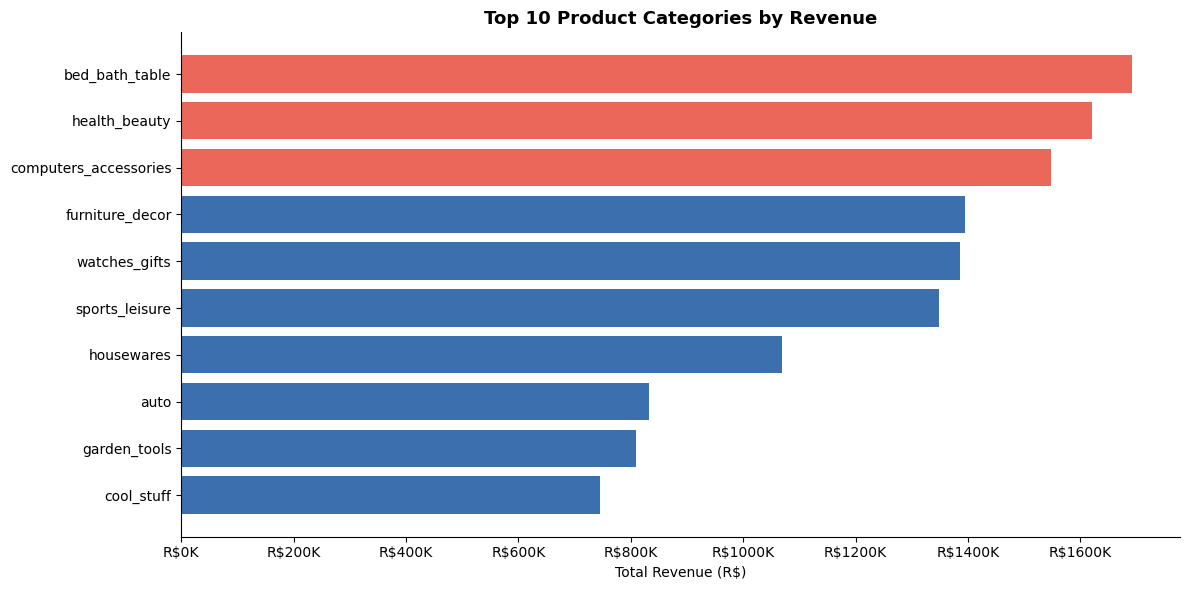

In [112]:
query1 = """
SELECT 
product_category_name_english AS category,
COUNT(DISTINCT order_id) AS total_orders,
ROUND(SUM(total_payment), 2) AS total_revenue
FROM orders
WHERE product_category_name_english != 'Unknown'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10
"""
top_categories = pd.read_sql(query1, conn)
print("\n" + "=" * 55)
print("SQL QUERY 1 — Top 10 Categories by Revenue")
print("=" * 55)
print(top_categories.to_string(index=False))
fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ["#E74C3C" if i < 3 else "#1A56A0" for i in range(len(top_categories))]
ax.barh(top_categories["category"][::-1], top_categories["total_revenue"][::-1],
        color=colors_bar[::-1], alpha=0.85)
ax.set_title("Top 10 Product Categories by Revenue", fontweight="bold", fontsize=13)
ax.set_xlabel("Total Revenue (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step3_top_categories.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 2 — Monthly Revenue Trend
     month  orders    revenue
2017-11-01    7283 1546527.09
2017-12-01    5511 1019380.00
2018-01-01    7066 1371378.22
2018-02-01    6551 1278718.85
2018-03-01    7003 1435458.33
2018-04-01    6798 1466607.15
2018-05-01    6748 1480465.63
2018-06-01    6095 1285352.15
2018-07-01    6156 1306707.42
2018-08-01    6351 1211240.09


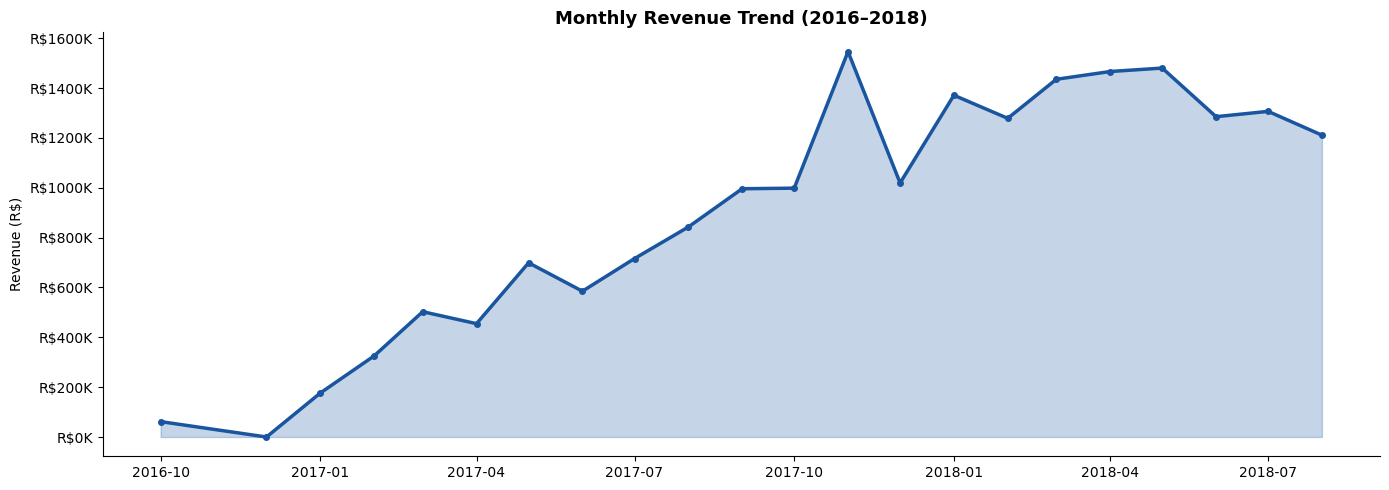

In [113]:
query2 = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS month,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(total_payment), 2) AS revenue
FROM orders
GROUP BY month
ORDER BY month
"""

monthly = pd.read_sql(query2, conn)
monthly["month"] = pd.to_datetime(monthly["month"])
print("\n" + "=" * 55)
print("SQL QUERY 2 — Monthly Revenue Trend")
print("=" * 55)
print(monthly.tail(10).to_string(index=False))
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly["month"], monthly["revenue"], alpha=0.25, color="#1A56A0")
ax.plot(monthly["month"], monthly["revenue"], color="#1A56A0", linewidth=2.5, marker="o", markersize=4)
ax.set_title("Monthly Revenue Trend (2016–2018)", fontweight="bold", fontsize=13)
ax.set_ylabel("Revenue (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step3_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 3 — Top 10 States by Revenue
state  total_orders  total_revenue  avg_review
   SP         40488     7401216.28        4.18
   RJ         12345     2686737.74        3.89
   MG         11352     2280092.83        4.13
   RS          5342     1109874.73        4.09
   PR          4923     1030822.39        4.15
   BA          3248      770283.95        3.87
   SC          3546      767093.97        4.06
   GO          1954      491526.18        4.06
   DF          2080      421374.86        4.06
   ES          1991      397725.88        4.03


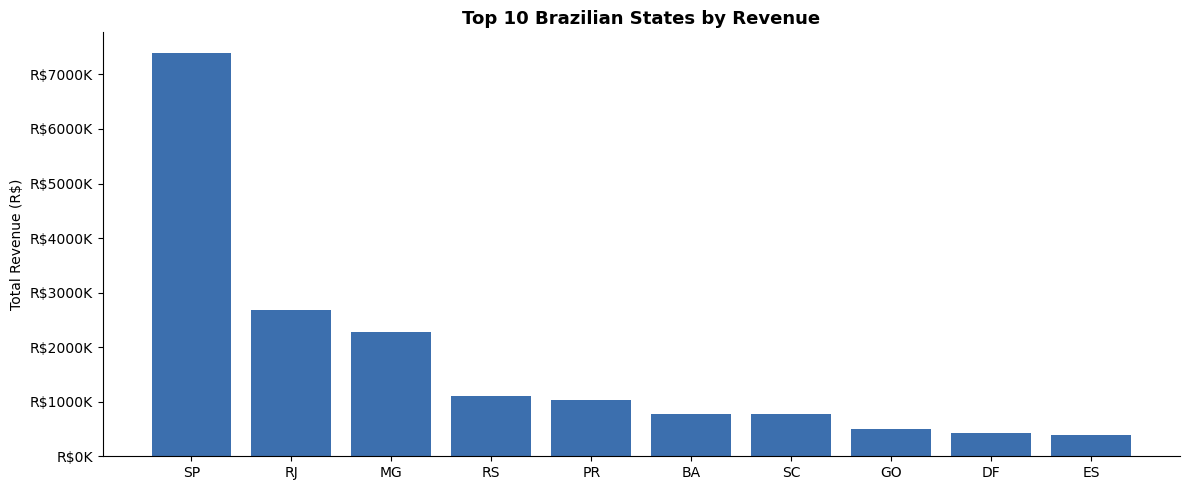

In [114]:
query3 = """
SELECT
    customer_state AS state,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_payment), 2) AS total_revenue,
    ROUND(AVG(review_score), 2) AS avg_review
FROM orders
GROUP BY state
ORDER BY total_revenue DESC
LIMIT 10
"""
top_states = pd.read_sql(query3, conn)
print("\n" + "=" * 55)
print("SQL QUERY 3 — Top 10 States by Revenue")
print("=" * 55)
print(top_states.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_states["state"], top_states["total_revenue"],
       color="#1A56A0", alpha=0.85)
ax.set_title("Top 10 Brazilian States by Revenue", fontweight="bold", fontsize=13)
ax.set_ylabel("Total Revenue (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step3_states_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 4 — Delivery Time vs Review Score
delivery_bucket  avg_review  order_count
       0-7 days        4.33        38720
      8-14 days        4.20        41716
     15-21 days        4.03        17479
       22+ days        3.00        12226


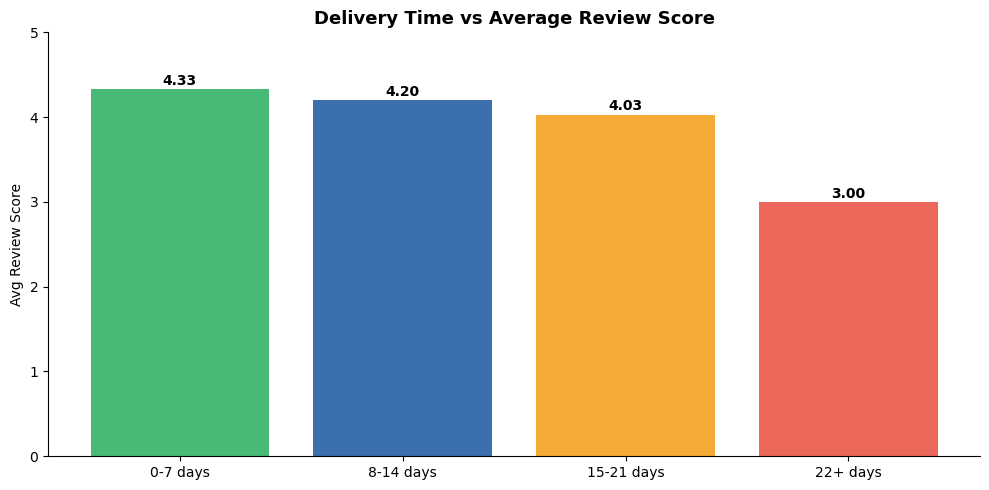

In [115]:
query4 = """
SELECT
    CASE
        WHEN delivery_days <= 7  THEN '0-7 days'
        WHEN delivery_days <= 14 THEN '8-14 days'
        WHEN delivery_days <= 21 THEN '15-21 days'
        ELSE '22+ days'
    END AS delivery_bucket,
    ROUND(AVG(review_score), 2) AS avg_review,
    COUNT(*) AS order_count
FROM orders
GROUP BY delivery_bucket
ORDER BY avg_review DESC
"""
delivery_review = pd.read_sql(query4, conn)
print("\n" + "=" * 55)
print("SQL QUERY 4 — Delivery Time vs Review Score")
print("=" * 55)
print(delivery_review.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 5))
order_buckets = ["0-7 days","8-14 days","15-21 days","22+ days"]
delivery_review["delivery_bucket"] = pd.Categorical(
    delivery_review["delivery_bucket"], categories=order_buckets, ordered=True)
delivery_review = delivery_review.sort_values("delivery_bucket")
colors_del = ["#27AE60","#1A56A0","#F39C12","#E74C3C"]
bars = ax.bar(delivery_review["delivery_bucket"], delivery_review["avg_review"],
              color=colors_del, alpha=0.85)
ax.set_title("Delivery Time vs Average Review Score", fontweight="bold", fontsize=13)
ax.set_ylabel("Avg Review Score"); ax.set_ylim(0, 5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha="center", fontweight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step3_delivery_vs_review.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 5 — Payment Type Distribution
payment_type  count  avg_installments
 credit_card  83310               3.6
      boleto  22352               1.0
     voucher   2825               1.5
  debit_card   1651               1.0


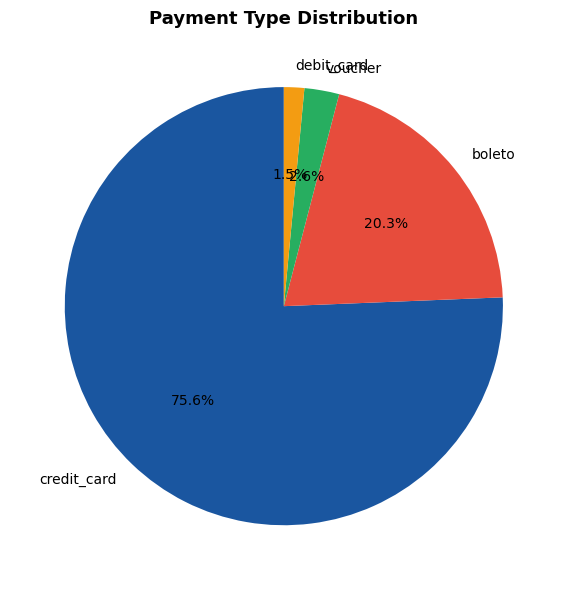

Chart 5 saved ✓

STEP 3 COMPLETE — KEY FINDINGS
  Top category   : bed_bath_table
  Top state      : SP
  Best delivery bucket review : 0-7 days (4.33)
  Top payment type : credit_card

Next step: Business Insights (Step 4)


In [116]:
query5 = """
SELECT
    payment_type,
    COUNT(*) AS count,
    ROUND(AVG(payment_installments), 1) AS avg_installments
FROM orders
WHERE payment_type IS NOT NULL
GROUP BY payment_type
ORDER BY count DESC
"""
payment_dist = pd.read_sql(query5, conn)
print("\n" + "=" * 55)
print("SQL QUERY 5 — Payment Type Distribution")
print("=" * 55)
print(payment_dist.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 6))
colors_pay = ["#1A56A0","#E74C3C","#27AE60","#F39C12","#8E44AD"]
ax.pie(payment_dist["count"], labels=payment_dist["payment_type"],
       colors=colors_pay[:len(payment_dist)],
       autopct="%1.1f%%", startangle=90)
ax.set_title("Payment Type Distribution", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("step3_payment_types.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved ✓")
 
conn.close()
 
print("\n" + "=" * 55)
print("STEP 3 COMPLETE — KEY FINDINGS")
print("=" * 55)
print(f"  Top category   : {top_categories.iloc[0]['category']}")
print(f"  Top state      : {top_states.iloc[0]['state']}")
print(f"  Best delivery bucket review : {delivery_review.iloc[0]['delivery_bucket']} ({delivery_review.iloc[0]['avg_review']})")
print(f"  Top payment type : {payment_dist.iloc[0]['payment_type']}")
print("\nNext step: Business Insights (Step 4)")
 

SQL QUERY 1 — Top 10 Sellers by Revenue
seller_short seller_state  total_orders  total_revenue  avg_review
    7c67e144           SP           972      505301.02        3.36
    1025f0e2           SP           910      306000.35        3.87
    4a3ca931           SP          1771      295715.74        3.84
    1f50f920           SP          1398      289794.71        4.00
    53243585           BA           348      279843.42        4.13
    da8622b1           SP          1311      271733.78        4.07
    4869f7a5           SP          1124      261532.48        4.15
    955fee92           SP          1261      232136.06        4.09
    fa1c13f2           SP           578      203262.00        4.38
    6560211a           SP          1819      176097.10        3.96


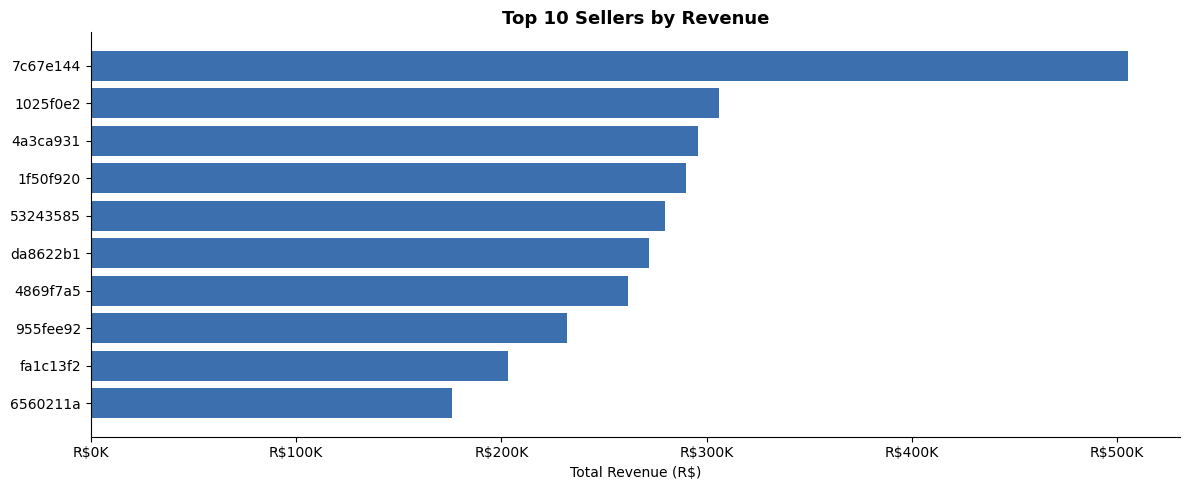

Chart 1 saved ✓


In [118]:
conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, index=False, if_exists="replace")
query1 = """
SELECT
    seller_id,
    seller_state,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_payment), 2) AS total_revenue,
    ROUND(AVG(review_score), 2) AS avg_review
FROM orders
GROUP BY seller_id
ORDER BY total_revenue DESC
LIMIT 10
"""
top_sellers = pd.read_sql(query1, conn)
top_sellers["seller_short"] = top_sellers["seller_id"].str[:8]
print("=" * 55)
print("SQL QUERY 1 — Top 10 Sellers by Revenue")
print("=" * 55)
print(top_sellers[["seller_short","seller_state","total_orders","total_revenue","avg_review"]].to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_sellers["seller_short"][::-1], top_sellers["total_revenue"][::-1],
        color="#1A56A0", alpha=0.85)
ax.set_title("Top 10 Sellers by Revenue", fontweight="bold", fontsize=13)
ax.set_xlabel("Total Revenue (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step4_top_sellers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved ✓")

In [ ]:
print(bottom_states.columns.tolist())


SQL QUERY 2 — 10 Underperforming States
state  total_orders  total_revenue  avg_review  avg_delivery_days
   RR            40       11034.03        3.87               24.6
   AP            66       21011.63        4.25               23.7
   AC            80       24890.49        4.13               20.3
   AM           144       34315.13        4.14               25.3
   RO           243       65200.66        4.08               19.3
   TO           274       70934.12        4.16               17.0
   SE           333       85182.97        3.91               20.1
   AL           397      108425.07        3.83               24.0
   RN           473      114969.58        4.12               18.6
   PI           474      133043.51        3.97               18.3


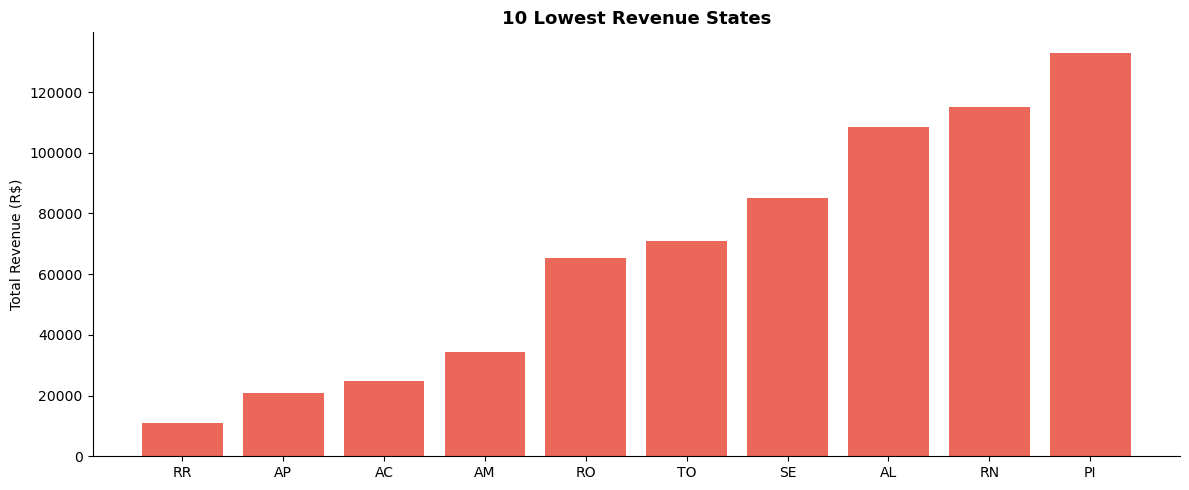

In [120]:
query2 = """
SELECT
    customer_state AS state,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_payment), 2) AS total_revenue,
    ROUND(AVG(review_score), 2) AS avg_review,
    ROUND(AVG(delivery_days), 1) AS avg_delivery_days
FROM orders
GROUP BY state
ORDER BY total_revenue ASC
LIMIT 10
"""
bottom_states = pd.read_sql(query2, conn)
print("\n" + "=" * 55)
print("SQL QUERY 2 — 10 Underperforming States")
print("=" * 55)
print(bottom_states.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(bottom_states["state"], bottom_states["total_revenue"],
       color="#E74C3C", alpha=0.85)
ax.set_title("10 Lowest Revenue States", fontweight="bold", fontsize=13)
ax.set_ylabel("Total Revenue (R$)")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step4_underperforming_states.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 3 — Seasonal Pattern by Month
month_name  total_orders  total_revenue
       Jan          7816     1547869.71
       Feb          8201     1604090.16
       Mar          9538     1938273.55
       Apr          9094     1921416.37
       May         10290     2179528.88
       Jun          9228     1870434.50
       Jul         10028     2022777.40
       Aug         10544     2053930.03
       Sep          4150      996207.31
       Oct          4743     1060356.56
       Nov          7283     1546527.09
       Dec          5512     1019399.62


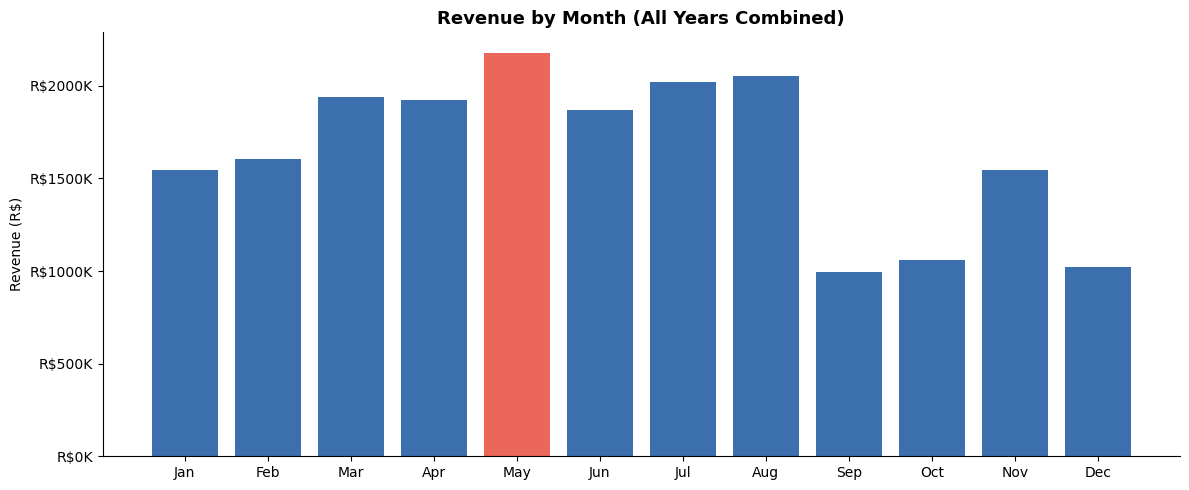

In [121]:
query3 = """
SELECT
    CAST(strftime('%m', order_purchase_timestamp) AS INTEGER) AS month_num,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_payment), 2) AS total_revenue
FROM orders
GROUP BY month_num
ORDER BY month_num
"""
seasonal = pd.read_sql(query3, conn)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal["month_name"] = seasonal["month_num"].apply(lambda x: month_names[x-1])
 
print("\n" + "=" * 55)
print("SQL QUERY 3 — Seasonal Pattern by Month")
print("=" * 55)
print(seasonal[["month_name","total_orders","total_revenue"]].to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 5))
colors_season = ["#E74C3C" if v == seasonal["total_revenue"].max() else "#1A56A0"
                 for v in seasonal["total_revenue"]]
ax.bar(seasonal["month_name"], seasonal["total_revenue"], color=colors_season, alpha=0.85)
ax.set_title("Revenue by Month (All Years Combined)", fontweight="bold", fontsize=13)
ax.set_ylabel("Revenue (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step4_seasonal_pattern.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 4 — Customer Repeat Purchase Rate
  Total unique customers : 96,427
  Repeat customers       : 0
  Repeat purchase rate   : 0.00%


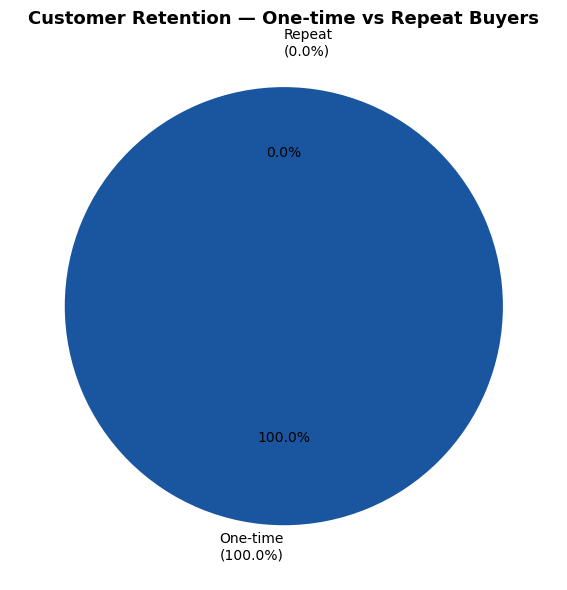

In [122]:
query4 = """
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS order_count
FROM orders
GROUP BY customer_id
"""
repeat_check = pd.read_sql(query4, conn)
repeat_customers = (repeat_check["order_count"] > 1).sum()
total_customers  = len(repeat_check)
repeat_pct = repeat_customers / total_customers * 100
 
print("\n" + "=" * 55)
print("SQL QUERY 4 — Customer Repeat Purchase Rate")
print("=" * 55)
print(f"  Total unique customers : {total_customers:,}")
print(f"  Repeat customers       : {repeat_customers:,}")
print(f"  Repeat purchase rate   : {repeat_pct:.2f}%")
 
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie([total_customers - repeat_customers, repeat_customers],
       labels=[f"One-time\n({100-repeat_pct:.1f}%)", f"Repeat\n({repeat_pct:.1f}%)"],
       colors=["#1A56A0","#27AE60"], autopct="%1.1f%%", startangle=90,
       explode=(0, 0.1))
ax.set_title("Customer Retention — One-time vs Repeat Buyers", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("step4_repeat_customers.png", dpi=150, bbox_inches="tight")
plt.show()


SQL QUERY 5 — 10 Worst Rated Categories (100+ orders)
                 category  order_count  avg_review
         office_furniture         1666        3.52
    fashion_male_clothing          125        3.77
          fixed_telephony          255        3.77
                    audio          362        3.85
             home_confort          428        3.86
           bed_bath_table        10950        3.94
    furniture_living_room          495        3.95
          furniture_decor         8155        3.96
construction_tools_safety          183        3.97
        home_construction          595        3.97


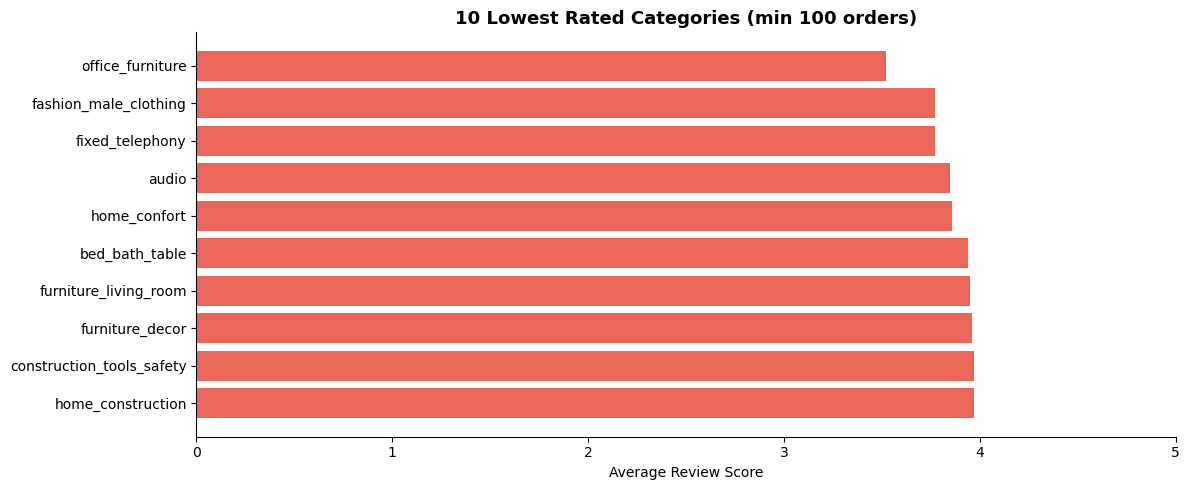

Chart 5 saved ✓

STEP 4 COMPLETE — KEY FINDINGS
  Top seller revenue        : R$505,301.02
  Lowest revenue state      : RR
  Peak revenue month        : May
  Repeat purchase rate      : 0.00%
  Worst rated category      : office_furniture (3.52)

Next step: Business Dashboard (Step 5)


In [123]:
query5 = """
SELECT
    product_category_name_english AS category,
    COUNT(*) AS order_count,
    ROUND(AVG(review_score), 2) AS avg_review
FROM orders
WHERE product_category_name_english != 'Unknown'
GROUP BY category
HAVING order_count > 100
ORDER BY avg_review ASC
LIMIT 10
"""
worst_categories = pd.read_sql(query5, conn)
print("\n" + "=" * 55)
print("SQL QUERY 5 — 10 Worst Rated Categories (100+ orders)")
print("=" * 55)
print(worst_categories.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(worst_categories["category"][::-1], worst_categories["avg_review"][::-1],
        color="#E74C3C", alpha=0.85)
ax.set_title("10 Lowest Rated Categories (min 100 orders)", fontweight="bold", fontsize=13)
ax.set_xlabel("Average Review Score")
ax.set_xlim(0, 5)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("step4_worst_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved ✓")
 
conn.close()
 
print("\n" + "=" * 55)
print("STEP 4 COMPLETE — KEY FINDINGS")
print("=" * 55)
print(f"  Top seller revenue        : R${top_sellers.iloc[0]['total_revenue']:,.2f}")
print(f"  Lowest revenue state      : {bottom_states.iloc[0]['state']}")
print(f"  Peak revenue month        : {seasonal.loc[seasonal['total_revenue'].idxmax(), 'month_name']}")
print(f"  Repeat purchase rate      : {repeat_pct:.2f}%")
print(f"  Worst rated category      : {worst_categories.iloc[0]['category']} ({worst_categories.iloc[0]['avg_review']})")
print("\nNext step: Business Dashboard (Step 5)")
 

In [124]:
BLUE, RED, GREEN, AMBER = "#1A56A0", "#E74C3C", "#27AE60", "#F39C12"
colors = [BLUE, RED, GREEN, AMBER, "#8E44AD", "#16A085", "#E67E22", "#2ECC71", "#9B59B6", "#1ABC9C"]

In [127]:
conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, index=False, if_exists="replace")
top_categories = pd.read_sql("""
    SELECT product_category_name_english AS category,
           ROUND(SUM(total_payment),2) AS revenue
    FROM orders WHERE category != 'Unknown'
    GROUP BY category ORDER BY revenue DESC LIMIT 10
""".replace("category != 'Unknown'", "product_category_name_english != 'Unknown'"), conn)
 
monthly = pd.read_sql("""
    SELECT strftime('%Y-%m', order_purchase_timestamp) AS month,
           ROUND(SUM(total_payment),2) AS revenue
    FROM orders GROUP BY month ORDER BY month
""", conn)
monthly["month"] = pd.to_datetime(monthly["month"])
 
top_states = pd.read_sql("""
    SELECT customer_state AS state, ROUND(SUM(total_payment),2) AS revenue
    FROM orders GROUP BY state ORDER BY revenue DESC LIMIT 10
""", conn)
 
delivery_review = pd.read_sql("""
    SELECT CASE WHEN delivery_days<=7 THEN '0-7 days'
                WHEN delivery_days<=14 THEN '8-14 days'
                WHEN delivery_days<=21 THEN '15-21 days'
                ELSE '22+ days' END AS bucket,
           ROUND(AVG(review_score),2) AS avg_review
    FROM orders GROUP BY bucket
""", conn)
order_buckets = ["0-7 days","8-14 days","15-21 days","22+ days"]
delivery_review["bucket"] = pd.Categorical(delivery_review["bucket"], categories=order_buckets, ordered=True)
delivery_review = delivery_review.sort_values("bucket")
 
seasonal = pd.read_sql("""
    SELECT CAST(strftime('%m', order_purchase_timestamp) AS INTEGER) AS month_num,
           ROUND(SUM(total_payment),2) AS revenue
    FROM orders GROUP BY month_num ORDER BY month_num
""", conn)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal["month_name"] = seasonal["month_num"].apply(lambda x: month_names[x-1])
 
worst_categories = pd.read_sql("""
    SELECT product_category_name_english AS category,
           COUNT(*) AS cnt, ROUND(AVG(review_score),2) AS avg_review
    FROM orders WHERE product_category_name_english != 'Unknown'
    GROUP BY category HAVING cnt > 100 ORDER BY avg_review ASC LIMIT 8
""", conn)
 
total_revenue = df["total_payment"].sum()
total_orders  = df["order_id"].nunique()
avg_review    = df["review_score"].mean()
late_pct      = df["is_late"].mean() * 100
avg_delivery  = df["delivery_days"].mean()
 
conn.close()
 

In [130]:
ig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor("#F8FAFC")
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.35,
                       top=0.93, bottom=0.04, left=0.06, right=0.97)
 
fig.text(0.5, 0.965, "Brazilian E-Commerce (Olist) — Business Intelligence Dashboard",
         ha="center", fontsize=20, fontweight="bold", color="#1A1A2E")
fig.text(0.5, 0.950, f"2016–2018 · {total_orders:,} Orders · Source: Kaggle Olist Dataset",
         ha="center", fontsize=11, color="#6B7280")
 
kpis = [
    (f"R${total_revenue/1e6:.1f}M", "Total Revenue", BLUE),
    (f"{total_orders:,}",           "Total Orders", GREEN),
    (f"{avg_review:.2f}/5",         "Avg Review Score", AMBER),
    (f"{avg_delivery:.1f} days",    "Avg Delivery Time", BLUE),
    (f"{late_pct:.1f}%",            "Late Deliveries", RED),
    ("São Paulo",                   "Top Revenue State", GREEN),
]
for i, (val, label, color) in enumerate(kpis):
    x = 0.06 + (i % 3) * 0.31
    y = 0.925 if i < 3 else 0.900
    fig.text(x + 0.12, y,       val,   ha="center", fontsize=17, fontweight="bold", color=color)
    fig.text(x + 0.12, y-0.014, label, ha="center", fontsize=9,  color="#6B7280")
 
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(monthly["month"], monthly["revenue"], alpha=0.25, color=BLUE)
ax1.plot(monthly["month"], monthly["revenue"], color=BLUE, linewidth=2, marker="o", markersize=3)
ax1.set_title("Monthly Revenue Trend (2016–2018)", fontweight="bold", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax1.spines[s].set_visible(False)
 
ax2 = fig.add_subplot(gs[0, 2])
colors_season = [RED if v == seasonal["revenue"].max() else BLUE for v in seasonal["revenue"]]
ax2.bar(seasonal["month_name"], seasonal["revenue"], color=colors_season, alpha=0.85)
ax2.set_title("Revenue by Month\n(All Years)", fontweight="bold", fontsize=10)
ax2.tick_params(axis="x", rotation=45, labelsize=7)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax2.spines[s].set_visible(False)
 
ax3 = fig.add_subplot(gs[1, :2])
colors_cat = [RED if i < 3 else BLUE for i in range(len(top_categories))]
ax3.barh(top_categories["category"][::-1], top_categories["revenue"][::-1],
         color=colors_cat[::-1], alpha=0.85)
ax3.set_title("Top 10 Product Categories by Revenue", fontweight="bold", fontsize=11)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
ax3.tick_params(labelsize=8)
for s in ["top","right"]: ax3.spines[s].set_visible(False)
 
ax4 = fig.add_subplot(gs[1, 2])
bars = ax4.bar(delivery_review["bucket"], delivery_review["avg_review"],
              color=[GREEN,BLUE,AMBER,RED], alpha=0.85)
ax4.set_title("Delivery Time vs\nReview Score", fontweight="bold", fontsize=10)
ax4.set_ylim(0, 5)
ax4.tick_params(axis="x", rotation=30, labelsize=7)
for bar in bars:
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"{bar.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")
for s in ["top","right"]: ax4.spines[s].set_visible(False)
 
ax5 = fig.add_subplot(gs[2, :2])
ax5.bar(top_states["state"], top_states["revenue"], color=BLUE, alpha=0.85)
ax5.set_title("Top 10 States by Revenue", fontweight="bold", fontsize=11)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
for s in ["top","right"]: ax5.spines[s].set_visible(False)
 
ax6 = fig.add_subplot(gs[2, 2])
ax6.barh(worst_categories["category"][::-1], worst_categories["avg_review"][::-1],
         color=RED, alpha=0.85)
ax6.set_title("Worst Rated Categories\n(100+ orders)", fontweight="bold", fontsize=10)
ax6.set_xlim(0, 5)
ax6.tick_params(labelsize=7)
for s in ["top","right"]: ax6.spines[s].set_visible(False)
 
ax7 = fig.add_subplot(gs[3, :])
ax7.axis("off")
ax7.set_facecolor("#EBF4FF")
insights = [
    "🛏️  bed_bath_table is the top revenue category — household goods dominate Brazilian e-commerce",
    "📍  São Paulo (SP) leads all states in revenue — Brazil's economic hub drives the majority of sales",
    "🚚  Delivery speed directly impacts satisfaction — 0-7 day deliveries score 4.33/5 vs 22+ days scoring far lower",
    "📉  10 lowest-revenue states show 17-25 day avg delivery — nearly double the fastest bucket, suggesting logistics gaps",
    "📅  May is the peak revenue month across all years combined",
    "🪑  office_furniture is the worst-rated category (3.52/5) among high-volume products — quality or shipping issue likely",
    "⚠️  Olist assigns unique customer IDs per order — true repeat-purchase tracking is not possible with this dataset alone",
]
ax7.set_title("Key Business Insights", fontweight="bold", fontsize=11, loc="left", pad=10)
for i, insight in enumerate(insights):
    ax7.text(0.01, 0.88 - i*0.13, insight, transform=ax7.transAxes,
             fontsize=9.5, color="#1A1A2E", verticalalignment="top")
 
plt.savefig("step5_ecommerce_dashboard.png", dpi=180, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()
print("Dashboard saved as step5_ecommerce_dashboard.png ✓")
print("\nSTEP 5 COMPLETE — Next: Streamlit App (Step 6)")

<Figure size 2200x2600 with 0 Axes>

Dashboard saved as step5_ecommerce_dashboard.png ✓

STEP 5 COMPLETE — Next: Streamlit App (Step 6)
